# Beschreibung #

# DPCA-Eigenwerte für Tennessee Eastman Process (TEP)

Dieses Notebook berechnet für jede Fehlerklasse (`faultNumber` 0-20) und jeden
Simulationslauf (`simulationRun`) die **DPCA-Eigenwerte** (Dynamic PCA) des
jeweiligen Runs und fasst diese anschließend über die 500 Läufe pro
Fehlerklasse mittels Mittelwert und Standardabweichung zusammen.

Struktur und Konventionen sind identisch zu `PCA_eigenwerte.ipynb` — der
einzige methodische Unterschied ist die **Lag-Erweiterung** der Datenmatrix
vor der PCA.

**Datensatz**

Kaggle "tep-csv" (afrniomelo):
https://www.kaggle.com/datasets/afrniomelo/tep-csv

- `TEP_FaultFree_Training.csv`  (faultNumber = 0)
- `TEP_Faulty_Training.csv`     (faultNumber = 1..20)

Beide Dateien müssen im aktuellen Arbeitsverzeichnis liegen.

Eigenschaften des Datensatzes (laut Kaggle-Doku):
- Sampling-Intervall: alle 3 Minuten.
- Training: 500 Samples pro Run (= 25 h Simulationsdauer).
- Faulty Training: Fehler wird **1 Stunde nach Simulationsstart** injiziert
  → 60 min / 3 min = **20 Samples Vorlauf**, erstes Post-Fault-Sample ist
  `sample == 21`.

**Konzept**

- **DPCA** (Ku, Storer & Georgakis 1995): an jeden Zeitpunkt werden `L`
  zeitverzögerte Kopien der 52 Prozessvariablen angehängt,
  `z_t = [x_t, x_{t-1}, …, x_{t-L}]`. Die lag-erweiterte Matrix hat
  `52·(L+1)` Spalten und `T−L` Zeilen — mit dem Standardwert `L = 2` also
  **(478, 156)** pro Post-Fault-Run. Statische PCA sieht nur die
  Querkorrelationen der Variablen *zum selben Zeitpunkt*; DPCA macht
  zusätzlich die **Auto- und Kreuzkorrelationen über die Zeit** sichtbar.
  Das Eigenwertspektrum trägt damit Information über die *Dynamik* des
  Prozesses — konzeptionell zwischen PCA (rein statisch) und DyCA
  (explizit dynamisch über Zeitableitungen).
- **Aktive Vorverarbeitung: `X_scaled = X - X.mean()`** (`global_mean`,
  skalarer Gesamtmittelwert) — exakt die Konvention aus
  `PCA_eigenwerte.ipynb`/`DyCA_Eigenwerte.ipynb`. Die Roh-Varianzen bleiben
  erhalten, die Hauptkomponenten werden also von den varianzstärksten
  Rohvariablen dominiert. Ein `StandardScaler` wird trotzdem auf
  Normalbetrieb (`faultNumber == 0`) gefittet und steht als Alternative
  bereit (`X_scaled = scaler.transform(X)`); dann gehen alle Variablen und
  ihre verzögerten Kopien gleichgewichtet ein.
- Pro Kombination (`faultNumber`, `simulationRun`) wird auf der
  lag-erweiterten Matrix eine eigene **PCA gefittet** (alle Komponenten,
  `svd_solver="full"`). Übernommen wird `explained_variance_ratio_` — die
  auf die Gesamtvarianz normierten Eigenwerte (Summe je Run = 1),
  absteigend sortiert: `dpca_1 … dpca_156`.
- Bei Fehlerklassen 1-20 werden die **Pre-Fault-Samples** (`sample < 21`)
  verworfen. Konsequenz: Fault 0 nutzt 500 Samples → 498 Zeilen nach dem
  Stacking, Fault 1-20 jeweils 480 → 478 Zeilen. Beides liegt deutlich
  über den 156 Dimensionen; die Kovarianzschätzung ist aber spürbar
  rauschiger als im 52-dimensionalen PCA-Fall (478/156 ≈ 3 gegenüber
  480/52 ≈ 9) — das ist der Preis der Lag-Erweiterung.
- **Noise-Subspace:** die verzögerten Kopien sind wegen des trägen
  Prozesses (3-min-Sampling) stark korreliert; zusätzlich zu den
  quasi-linearen Bilanz-Abhängigkeiten der 52 Variablen entstehen dadurch
  viele nahezu verschwindende Eigenwerte. Genau diese Redundanz
  (= zeitliche Vorhersagbarkeit) ist Teil der DPCA-Signatur. Dargestellt
  werden wie im PCA-Notebook nur die ersten Komponenten (`k_max = 25`
  in den Linienplots, `k_bar = 10` im Balkenplot).
- Über die 500 Läufe einer Fehlerklasse werden für jeden Eigenwertindex
  Mittelwert und Standardabweichung gebildet.


# Imports #

In [1]:
# Standard-Imports
import numpy as np
import pandas as pd

# Scikit-Learn fuer Standardisierung und PCA
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

# Optional: Fortschrittsbalken fuer lange Schleifen
try:
    from tqdm.auto import tqdm
    tqdm_available = True
except ImportError:
    tqdm_available = False

# Parameter #

In [2]:
# ===== Pfade zu den TEP-CSV-Dateien =====
PATH_FAULTFREE_TRAIN = "TEP_FaultFree_Training.csv"
PATH_FAULTY_TRAIN    = "TEP_Faulty_Training.csv"

# ===== Prozessvariablen (wie im PCA-/DyCA-Notebook) =====
XMEAS_COLS = [f"xmeas_{i}" for i in range(1, 42)]
XMV_COLS   = [f"xmv_{i}"   for i in range(1, 12)]
PROC_COLS  = XMEAS_COLS + XMV_COLS

META_COLS  = ["faultNumber", "simulationRun", "sample"]

# ===== DPCA-Parameter =====
# L = Anzahl der zeitverzoegerten Kopien (Lags), die an den Zustands-
# vektor angehaengt werden: z_t = [x_t, x_{t-1}, ..., x_{t-L}].
# L=2 ist die Standardwahl von Ku, Storer & Georgakis (1995) fuer TEP.
# Die lag-erweiterte Matrix hat 52*(L+1) Spalten (L=2 -> 156) und
# T-L Zeilen; entsprechend gibt es 52*(L+1) Eigenwerte pro Run.
DPCA_LAGS = 2

# Erster Sample-Index, der als 'post-fault' gilt (siehe Beschreibung).
PRE_FAULT_CUTOFF = 21

# Daten laden & Spalten prüfen #

In [3]:
# ============================================================
# Trainingsdaten laden
# ============================================================
# Beide Trainings-CSVs muessen im aktuellen Arbeitsverzeichnis liegen.
#   - TEP_FaultFree_Training.csv : nur faultNumber == 0
#     -> 500 simulationRuns x 500 samples = 250 000 Zeilen
#   - TEP_Faulty_Training.csv    : faultNumber 1..20
#     -> 20 faults x 500 runs x 500 samples = 5 000 000 Zeilen

df_ff_train     = pd.read_csv(PATH_FAULTFREE_TRAIN)
df_faulty_train = pd.read_csv(PATH_FAULTY_TRAIN)

# Nur die benoetigten Spalten behalten (Metadaten + Prozessvariablen).
df_ff_train     = df_ff_train[META_COLS + PROC_COLS]
df_faulty_train = df_faulty_train[META_COLS + PROC_COLS]

print("FaultFree_Training shape:", df_ff_train.shape)
print("Faulty_Training shape   :", df_faulty_train.shape)

# ------------------------------------------------------------
# Spalten-Check
# ------------------------------------------------------------
# Diese drei Spalten brauchen wir spaeter zum Gruppieren der Daten
# nach Fehlerklasse und Simulationslauf.
for col in META_COLS:
    if col not in df_ff_train.columns:
        raise ValueError(f"Spalte {col} fehlt in TEP_FaultFree_Training.csv")
    if col not in df_faulty_train.columns:
        raise ValueError(f"Spalte {col} fehlt in TEP_Faulty_Training.csv")

print("Anzahl Prozessvariablen:", len(PROC_COLS))
print("Beispiel-Variablen:", PROC_COLS[:5])

FaultFree_Training shape: (250000, 55)
Faulty_Training shape   : (5000000, 55)
Anzahl Prozessvariablen: 52
Beispiel-Variablen: ['xmeas_1', 'xmeas_2', 'xmeas_3', 'xmeas_4', 'xmeas_5']


# StandardScaler auf FaultFree_Training fitten (wird in der Schleife angewandt) #

In [4]:
# ============================================================
# StandardScaler auf FaultFree_Training (Normalbetrieb) fitten
# ============================================================
# Der Scaler wird hier GEFITTET, aktuell aber NICHT angewandt: aktiv ist
# X_scaled = X - X.mean() (global_mean) in
# compute_dpca_eigenvalues_per_run - exakt die Konvention aus
# PCA_eigenwerte.ipynb / DyCA_Eigenwerte.ipynb. Umschalten auf
# scaler.transform(X) kostet nur diese eine Zeile (siehe Kommentar dort).

scaler = StandardScaler()
scaler.fit(df_ff_train[PROC_COLS].values)

print("StandardScaler auf FaultFree_Training angepasst.")
print("  Anzahl Prozessvariablen:", len(PROC_COLS))
print("  Mittelwerte (Auszug):    ", np.round(scaler.mean_[:5], 4))
print("  Std-Werte (Auszug):      ", np.round(scaler.scale_[:5], 4))

StandardScaler auf FaultFree_Training angepasst.
  Anzahl Prozessvariablen: 52
  Mittelwerte (Auszug):     [2.5050000e-01 3.6637857e+03 4.5088198e+03 9.3471000e+00 2.6902200e+01]
  Std-Werte (Auszug):       [3.09000e-02 3.40063e+01 3.92153e+01 8.57000e-02 2.11500e-01]


# Trainingsdaten zusammenführen (Fault 0-20) #

In [5]:
# ============================================================
# Trainingsdaten zusammenfuehren (Fault 0..20 in EINEM DataFrame)
# ============================================================
# Wir wollen anschliessend EINE Schleife ueber alle Kombinationen
# (faultNumber, simulationRun) laufen lassen.
#
# Globale Sortierung nach (Fault, Run, Sample): die Lag-Erweiterung
# haengt zeitverzoegerte Kopien an - die Zeilen jeder Gruppe muessen
# dafuer zeitlich geordnet vorliegen (wie bei DyCA, anders als bei der
# permutationsinvarianten statischen PCA). Die per-Run-Funktion sortiert
# unten zusaetzlich defensiv.

df_all = pd.concat([df_ff_train, df_faulty_train], ignore_index=True)
df_all = df_all.sort_values(
    ["faultNumber", "simulationRun", "sample"]
).reset_index(drop=True)

print("Kombinierte Trainingsdaten shape:", df_all.shape)
print("FaultNumbers im kombinierten Datensatz:",
      sorted(df_all["faultNumber"].unique()))

Kombinierte Trainingsdaten shape: (5250000, 55)
FaultNumbers im kombinierten Datensatz: [np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10), np.int64(11), np.int64(12), np.int64(13), np.int64(14), np.int64(15), np.int64(16), np.int64(17), np.int64(18), np.int64(19), np.int64(20)]


# Funktion: DPCA-Eigenwerte pro Run #

In [6]:
def lag_stack(X, lags):
    """Haengt zeitverzoegerte Kopien der Variablen an (Dynamic PCA).

    Zeile t der Rueckgabe ist [x_t, x_{t-1}, ..., x_{t-lags}] - die
    ersten `lags` Zeitpunkte entfallen, weil ihnen die Vergangenheit
    fehlt.

    Parameter
    ---------
    X : np.ndarray
        Messmatrix (n_samples, n_features), zeitlich geordnet.
    lags : int
        Anzahl der angehaengten Verzoegerungen L.

    Rueckgabewert
    -------------
    Z : np.ndarray
        Lag-erweiterte Matrix (n_samples - lags, n_features * (lags + 1)).
    """
    T = X.shape[0]
    cols = [X[lags - l: T - l] for l in range(lags + 1)]
    return np.hstack(cols)


def compute_dpca_eigenvalues_per_run(df, proc_cols, scaler, lags=DPCA_LAGS,
                                     drop_pre_fault=True,
                                     pre_fault_cutoff=PRE_FAULT_CUTOFF):
    """
    Berechnet pro Kombination aus faultNumber und simulationRun die
    DPCA-Eigenwerte dieses Runs - analog zu compute_eigenvalues_per_run
    im PCA-Notebook, nur mit Lag-Erweiterung vor der PCA.

    Vorgehen pro Run:
      1. Zeitlich sortieren und (bei Fault != 0) Pre-Fault verwerfen.
      2. Vorverarbeiten: X_scaled = X - X.mean() - Abzug des skalaren
         Gesamtmittelwerts (global_mean). Alternative in derselben
         Zeile: scaler.transform(X).
      3. Lag-Erweiterung: Z = lag_stack(X_scaled, lags)
         -> (T - lags, 52 * (lags + 1)).
      4. PCA mit allen Komponenten auf Z fitten (svd_solver="full").
      5. `explained_variance_ratio_` als Eigenwertvektor uebernehmen -
         die auf die Gesamtvarianz NORMIERTEN Eigenwerte der
         lag-erweiterten Kovarianzmatrix (Summe je Run = 1), absteigend
         sortiert. Fuer die unnormierten Eigenwerte waere
         explained_variance_ zu nehmen.

    Parameter
    ---------
    df : pd.DataFrame
        Trainingsdaten mit Spalten 'faultNumber', 'simulationRun',
        'sample' und den Prozessvariablen.
    proc_cols : list[str]
        Namen der Prozessvariablen (xmeas_*, xmv_*).
    scaler : StandardScaler
        Auf FaultFree_Training angepasster StandardScaler. Aktuell
        UNGENUTZT (aktiv ist X_scaled = X - X.mean()); wird erst beim
        Umschalten auf scaler.transform(X) gebraucht.
    lags : int
        Anzahl der Verzoegerungen L (siehe Parameter-Zelle).
    drop_pre_fault : bool
        Wenn True, werden bei Fault != 0 alle Samples mit
        sample < pre_fault_cutoff verworfen.
    pre_fault_cutoff : int
        Erster Sample-Index, der als 'post-fault' gilt.

    Rueckgabewert
    -------------
    eigenvalues_df : pd.DataFrame
        Eine Zeile pro (faultNumber, simulationRun). Spalten:
            'faultNumber', 'simulationRun',
            'dpca_1', 'dpca_2', ..., 'dpca_K'
        mit K = 52 * (lags + 1); dpca_i sind die absteigend sortierten
        VARIANZANTEILE (dpca_1 = groesster Anteil, Summe je Zeile = 1).
    """

    # ----------------------------------------------------------
    # Schritt 1: Gruppierung nach (Fault, Run)
    # ----------------------------------------------------------
    grouped = df.groupby(["faultNumber", "simulationRun"], sort=True)

    rows = []
    iterator = grouped
    if tqdm_available:
        iterator = tqdm(grouped, desc="Berechne DPCA-Eigenwerte pro Run")

    # ----------------------------------------------------------
    # Schritt 2: Pro Gruppe (Fault, Run) Lag-Stacking + PCA
    # ----------------------------------------------------------
    for (fault, run), group in iterator:

        # 2a) Defensive zeitliche Sortierung - lag_stack setzt geordnete
        # Zeilen voraus (die aufrufende Zelle sortiert bereits global).
        group = group.sort_values("sample")

        # 2b) Pre-Fault-Bereich verwerfen (nur bei echten Faults).
        if drop_pre_fault and fault != 0:
            group = group[group["sample"] >= pre_fault_cutoff]

        # 2c) Reine Messmatrix dieses Runs extrahieren.
        # Shape: (n_samples_pro_run, 52) = z.B. (480, 52)
        X = group[proc_cols].values

        # 2d) Vorverarbeitung: Abzug des skalaren Gesamtmittelwerts
        # (global_mean) - die Rohvarianzen bleiben erhalten und dominieren
        # die lag-erweiterte PCA. (Alternative: scaler.transform(X).)
        X_scaled = X - X.mean()  # global_mean aktiv | Alternative: X_scaled = scaler.transform(X)

        # 2e) Lag-Erweiterung: (T, 52) -> (T - lags, 52 * (lags + 1)).
        Z = lag_stack(X_scaled, lags)

        # 2f) PCA pro Run auf der lag-erweiterten Matrix fitten.
        # n_components=None + svd_solver='full' -> alle
        # min(n_samples, n_features) = 156 Komponenten (auch die aus dem
        # Noise-Subspace).
        pca_run = PCA(n_components=None, svd_solver="full")
        pca_run.fit(Z)

        # 2g) Eigenwerte uebernehmen (Varianzanteile, Summe = 1, bereits
        # absteigend sortiert und reell).
        eigvals = pca_run.explained_variance_ratio_

        row = {
            "faultNumber":   fault,
            "simulationRun": run,
        }
        for i, val in enumerate(eigvals, start=1):
            row[f"dpca_{i}"] = float(val)
        rows.append(row)

    # ----------------------------------------------------------
    # Schritt 3: Alle Zeilen zu einem DataFrame zusammenfuehren
    # ----------------------------------------------------------
    eigenvalues_df = pd.DataFrame(rows)
    return eigenvalues_df

# Anwendung: DPCA-Eigenwerte für alle (Fault, Run)-Kombinationen #

In [7]:
# DPCA-Eigenwerte fuer alle Faults und Runs in den Trainingsdaten berechnen.
#
# Pre-Fault-Cutoff = 21:
#   Laut Kaggle-Doku (afrniomelo/tep-csv) wird der Fehler im Faulty
#   Training 1 Stunde nach Simulationsstart injiziert. Bei einem
#   Sampling-Intervall von 3 min entspricht das 20 Samples Vorlauf,
#   d.h. das erste Post-Fault-Sample hat sample == 21.

dpca_eigenvalues_per_run = compute_dpca_eigenvalues_per_run(
    df=df_all,
    proc_cols=PROC_COLS,
    scaler=scaler,
    lags=DPCA_LAGS,
    drop_pre_fault=True,
    pre_fault_cutoff=PRE_FAULT_CUTOFF,
)

print("DPCA-Eigenwerte pro Run shape:", dpca_eigenvalues_per_run.shape)
dpca_eigenvalues_per_run.head()

Berechne DPCA-Eigenwerte pro Run:   0%|          | 0/10500 [00:00<?, ?it/s]

DPCA-Eigenwerte pro Run shape: (10500, 158)


,faultNumber,simulationRun,dpca_1,dpca_2,dpca_3,dpca_4,dpca_5,dpca_6,dpca_7,dpca_8,...,dpca_147,dpca_148,dpca_149,dpca_150,dpca_151,dpca_152,dpca_153,dpca_154,dpca_155,dpca_156
0,0,1,0.327481,0.200619,0.142276,0.112729,0.089133,0.066599,0.029972,0.016955,...,4.570292e-10,3.003740e-10,9.755979e-11,8.877982e-11,8.269905e-12,7.639573e-12,7.097903e-12,6.901976e-12,6.545777e-12,6.419501e-12
1,0,2,0.323807,0.195098,0.123324,0.100350,0.076078,0.067183,0.052117,0.049420,...,3.898484e-10,3.019052e-10,7.777803e-11,7.349748e-11,7.158435e-12,6.608005e-12,6.339651e-12,5.948886e-12,5.527731e-12,4.546368e-12
2,0,3,0.280967,0.200192,0.127537,0.113397,0.090986,0.082202,0.063741,0.026586,...,4.670380e-10,3.593330e-10,7.835034e-11,6.896915e-11,7.401476e-12,7.260063e-12,6.813333e-12,6.187600e-12,5.607756e-12,5.092177e-12
3,0,4,0.288930,0.204825,0.139441,0.126061,0.097578,0.060477,0.040671,0.028067,...,4.017481e-10,2.885157e-10,9.546313e-11,8.155269e-11,7.903414e-12,7.188341e-12,6.299820e-12,5.916321e-12,5.542634e-12,5.188528e-12
4,0,5,0.379033,0.171654,0.135233,0.102819,0.078422,0.060877,0.038730,0.020040,...,3.566210e-10,2.095235e-10,8.657373e-11,7.647753e-11,7.520977e-12,7.302475e-12,6.835001e-12,6.719224e-12,6.226816e-12,5.390674e-12


# Aggregation: Mittelwert & Standardabweichung pro Fehlerklasse #

In [8]:
# ============================================================
# Pro Fehlerklasse: Mittelwert und Standardabweichung jedes Eigenwerts
# ============================================================
# Ausgangspunkt: dpca_eigenvalues_per_run hat eine Zeile pro (Fault, Run)
# mit den 156 Eigenwerten als Spalten dpca_1 .. dpca_156.
# Ziel:          eine Zeile pro Fault mit Mittelwert UND Std jedes
#                Eigenwerts ueber die 500 Runs der Klasse.

# Spalten-Liste der Eigenwerte (alles, was mit "dpca_" anfaengt).
dpca_cols = [c for c in dpca_eigenvalues_per_run.columns
             if c.startswith("dpca_")]

# Gruppieren nach faultNumber und in EINEM Schritt mean+std je
# Eigenwert-Spalte aggregieren. pandas-Std benutzt ddof=1
# (Stichproben-Std), passt fuer N=500.
agg = dpca_eigenvalues_per_run.groupby("faultNumber")[dpca_cols].agg(["mean", "std"])

# MultiIndex-Spalten ('dpca_1', 'mean') -> 'dpca_1_mean' flachklopfen.
agg.columns = [f"{col}_{stat}" for col, stat in agg.columns]

# faultNumber war Group-Key (Index) - jetzt wieder als normale Spalte.
agg = agg.reset_index()

print("Aggregierte DPCA-Eigenwert-Statistiken pro Fault:")
print("  shape:", agg.shape)
agg.head()

Aggregierte DPCA-Eigenwert-Statistiken pro Fault:
  shape: (21, 313)


C:\Users\groetsch22395\AppData\Local\Temp\ipykernel_8908\2288697676.py:22: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  agg = agg.reset_index()


,faultNumber,dpca_1_mean,dpca_1_std,dpca_2_mean,dpca_2_std,dpca_3_mean,dpca_3_std,dpca_4_mean,dpca_4_std,dpca_5_mean,...,dpca_152_mean,dpca_152_std,dpca_153_mean,dpca_153_std,dpca_154_mean,dpca_154_std,dpca_155_mean,dpca_155_std,dpca_156_mean,dpca_156_std
0,0,0.314797,0.034851,0.200869,0.020442,0.138187,0.012884,0.114520,0.010511,0.084409,...,7.272059e-12,7.389026e-13,6.750828e-12,6.902316e-13,6.256390e-12,6.447699e-13,5.788007e-12,6.053470e-13,5.184784e-12,6.026134e-13
1,1,0.590026,0.042988,0.154242,0.011548,0.107171,0.015566,0.046605,0.008386,0.030975,...,1.568494e-12,2.609937e-13,1.448100e-12,2.371385e-13,1.343707e-12,2.220369e-13,1.238647e-12,2.062761e-13,1.094568e-12,1.864500e-13
2,2,0.532276,0.021580,0.216015,0.019562,0.074390,0.008625,0.051284,0.004407,0.042450,...,2.648957e-12,2.133025e-13,2.449860e-12,1.929182e-13,2.268766e-12,1.781139e-13,2.088098e-12,1.737542e-13,1.863704e-12,1.840324e-13
3,3,0.317070,0.035697,0.199913,0.020767,0.137489,0.012927,0.113708,0.010713,0.083875,...,7.077548e-12,7.807501e-13,6.556238e-12,7.114104e-13,6.097276e-12,6.667627e-13,5.625744e-12,6.384387e-13,5.017945e-12,6.200995e-13
4,4,0.317076,0.035612,0.199906,0.020740,0.137495,0.012922,0.113703,0.010693,0.083880,...,7.080580e-12,7.579008e-13,6.527626e-12,6.818099e-13,6.058986e-12,6.208680e-13,5.597594e-12,5.889216e-13,4.986452e-12,5.779720e-13


# Visualisierung: mittlere Eigenwertspektren je Fehlerklasse #

Anzahl Faults: 21
Anzahl Komponenten pro Fault (geplottet): 25 von 156


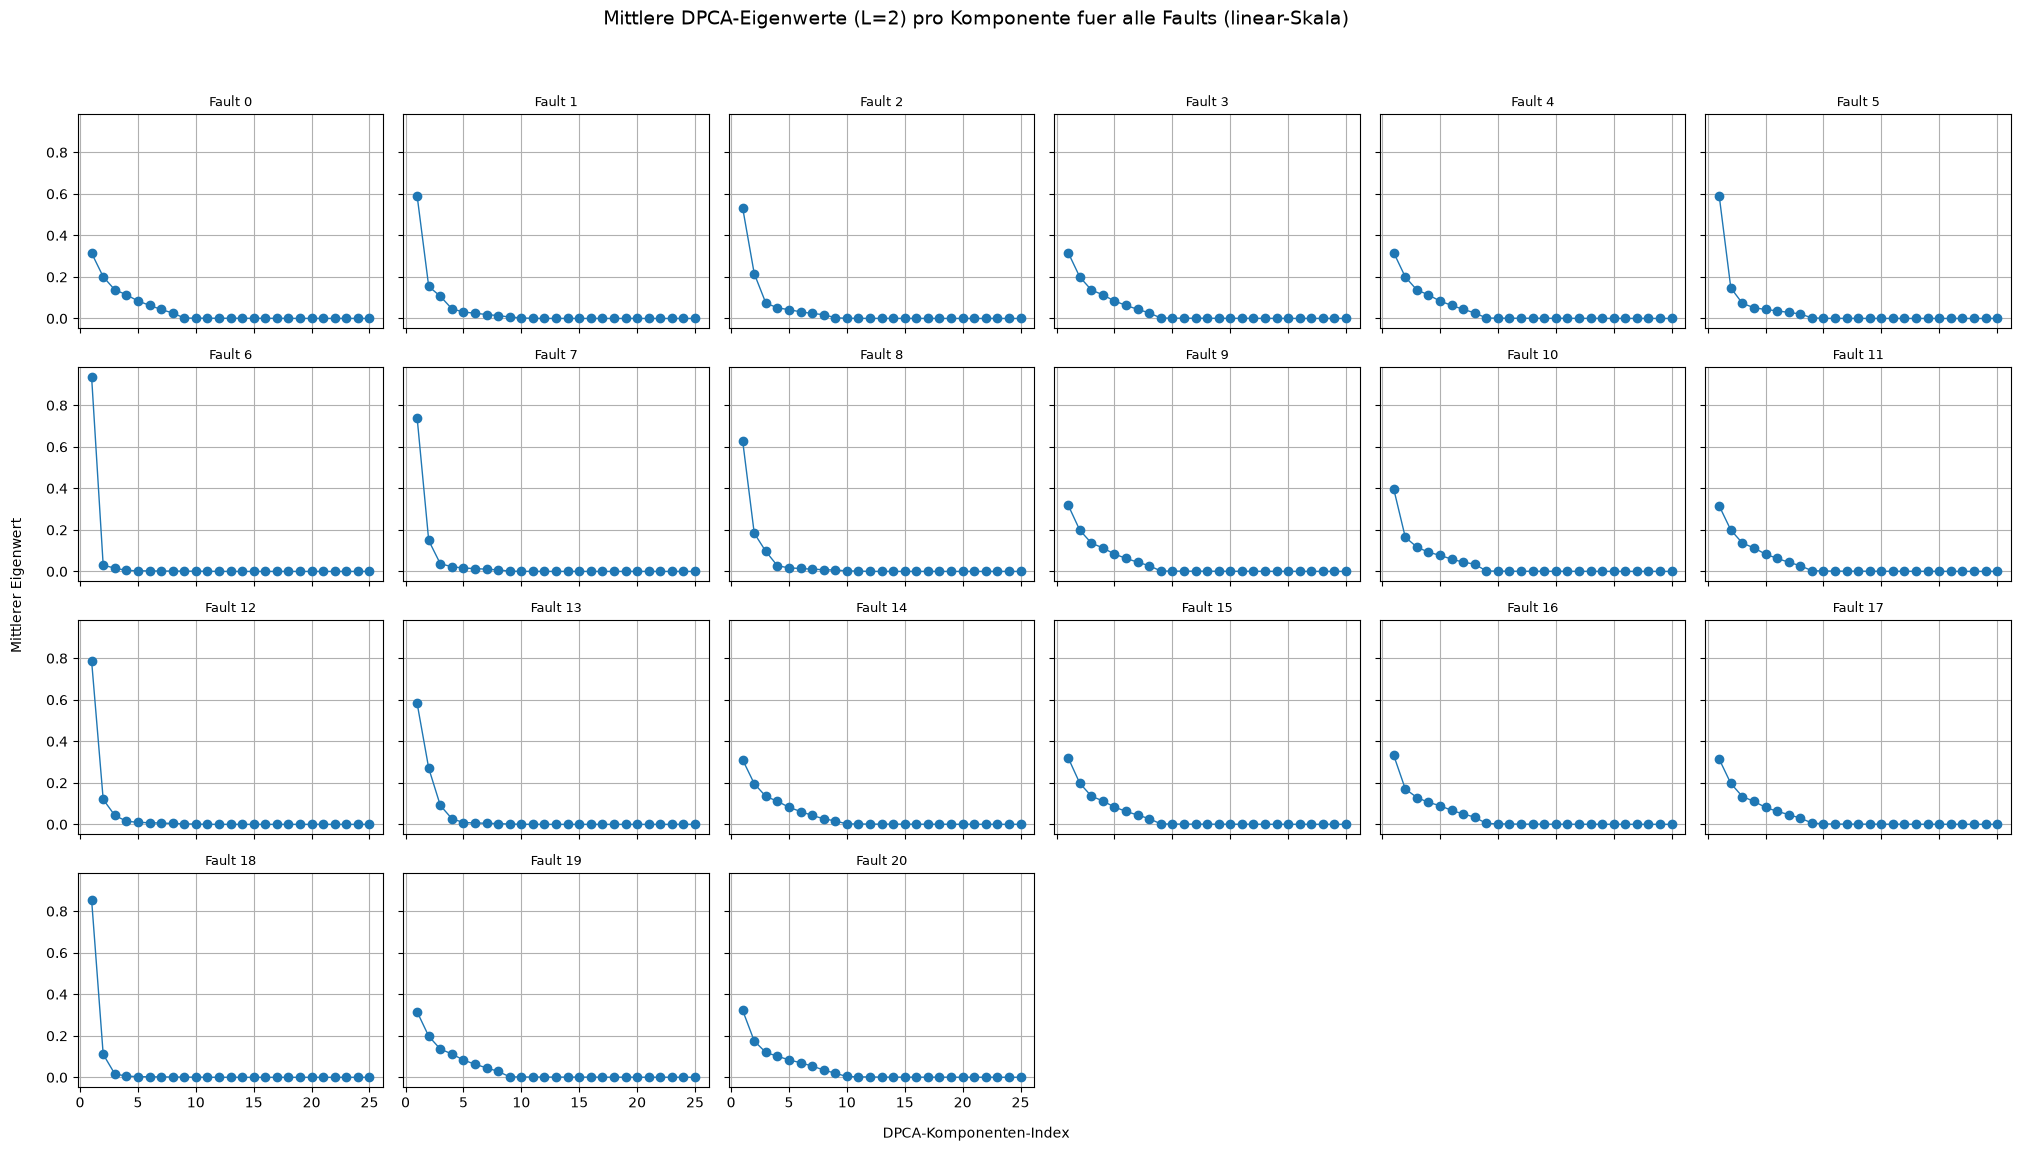

In [9]:
import matplotlib.pyplot as plt
import math

# ============================================================
# Visualisierung: ein Subplot pro Fehlerklasse, jeweils der mittlere
# Eigenwertverlauf ueber die ersten k Komponenten.
# ============================================================

# Welche Faults gibt es? Aus dem aggregierten DataFrame ablesen.
all_faults = sorted(agg["faultNumber"].unique())
n_faults   = len(all_faults)

# Nur die Mittelwert-Spalten (dpca_i_mean) fuer den Plot heraussuchen,
# aufsteigend nach Komponenten-Index sortiert (String-Sortierung wuerde
# dpca_10 vor dpca_2 stellen).
mean_cols = [
    c for c in agg.columns
    if c.startswith("dpca_") and c.endswith("_mean")
]
mean_cols = sorted(mean_cols, key=lambda c: int(c.split("_")[1]))
n_components_total = len(mean_cols)

# Eigenwertspektrum ueber 156 Dimensionen ist visuell unuebersichtlich
# und die hinteren Eigenwerte sind ohnehin nahe null (Noise-Subspace,
# durch die Lag-Redundanz noch ausgepraegter als bei der statischen PCA).
# Wir beschraenken uns auf die ersten k Komponenten - wie im PCA-Notebook.
k_max = 25
n_components = min(k_max, n_components_total)
mean_cols    = mean_cols[:n_components]

print("Anzahl Faults:", n_faults)
print("Anzahl Komponenten pro Fault (geplottet):", n_components,
      "von", n_components_total)


# ============================================================
# Hilfsfunktion: Transformation der Eigenwerte vor dem Plotten
# ============================================================
def transform_eigenvalues(vals, mode="log"):
    """
    Transformiert einen Vektor von Eigenwerten fuer die Darstellung.

    mode = "linear"   -> keine Transformation. Bei den normierten
                         Varianzanteilen (Summe = 1) gut lesbar fuer die
                         dominanten ersten Komponenten; der Noise-Tail
                         liegt optisch auf der Nulllinie.
    mode = "log"      -> log10(Eigenwert). Macht die Groessenordnungs-
                         Unterschiede zwischen Komponenten sichtbar.
    mode = "relative" -> Eigenwert / dpca_1. Zeigt nur noch das
                         "Profil" / die Form des Spektrums, unabhaengig
                         vom Absolutniveau einer Fault.
    """
    vals = np.asarray(vals, dtype=float)

    if mode == "linear":
        return vals

    if mode == "log":
        # log10(0) ist -inf -> kleinen Offset einsetzen, um Plot-NaNs zu vermeiden.
        eps = 1e-8
        return np.log10(np.maximum(vals, eps))

    if mode == "relative":
        if vals[0] <= 0:
            # Defensiver Fallback: bei dpca_1 <= 0 (numerisch entartet)
            # waere die Normierung undefiniert.
            return vals
        return vals / vals[0]

    raise ValueError(f"Unbekannter mode: {mode}")


# Darstellungsmodus:
#   "linear"   -> zeigt die dominanten ersten Varianzanteile direkt (aktuelle Wahl)
#   "log"      -> macht zusaetzlich den Noise-Tail sichtbar
#   "relative" -> wenn nur die Form des Spektrums interessiert (alle starten bei 1.0)
plot_mode = "linear"


# ============================================================
# Subplot-Raster aufbauen (z.B. 4 Zeilen x 6 Spalten fuer 21 Faults)
# ============================================================
max_cols = 6
n_cols   = min(max_cols, n_faults)
n_rows   = math.ceil(n_faults / n_cols)

# sharex/sharey=True: alle Subplots teilen sich Achsen -> Faults sind
# auf einen Blick vergleichbar.
fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(3.5 * n_cols, 3.0 * n_rows),
    sharex=True,
    sharey=True,
)
axes = np.array(axes).reshape(-1)

# x-Achse: Komponenten-Indizes 1..n_components
x = range(1, n_components + 1)

# Pro Fault einen Subplot fuellen.
for idx, f in enumerate(all_faults):
    ax  = axes[idx]
    row = agg[agg["faultNumber"] == f]

    if row.empty:
        ax.set_visible(False)
        continue

    means  = row[mean_cols].values.flatten()
    y_vals = transform_eigenvalues(means, mode=plot_mode)

    ax.plot(x, y_vals, marker="o", linewidth=1)
    ax.set_title(f"Fault {f}", fontsize=9)
    ax.grid(True)

# Unbenutzte Achsen ausblenden (21 Faults in 4x6=24-Raster).
for j in range(idx + 1, len(axes)):
    axes[j].set_visible(False)

# y-Achsen-Beschriftung passt sich an den gewaehlten Modus an.
if plot_mode == "log":
    y_label = "log10(Mittlerer Eigenwert)"
elif plot_mode == "relative":
    y_label = "Mittlerer Eigenwert / dpca_1"
else:
    y_label = "Mittlerer Eigenwert"

fig.suptitle(
    f"Mittlere DPCA-Eigenwerte (L={DPCA_LAGS}) pro Komponente fuer alle Faults ({plot_mode}-Skala)",
    fontsize=14,
)
fig.text(0.5,  0.04, "DPCA-Komponenten-Index", ha="center")
fig.text(0.04, 0.5,  y_label, va="center", rotation="vertical")

plt.tight_layout(rect=[0.05, 0.05, 1.0, 0.95])
plt.show()

# Visualisierung: Standardabweichungs-Spektren je Fehlerklasse #

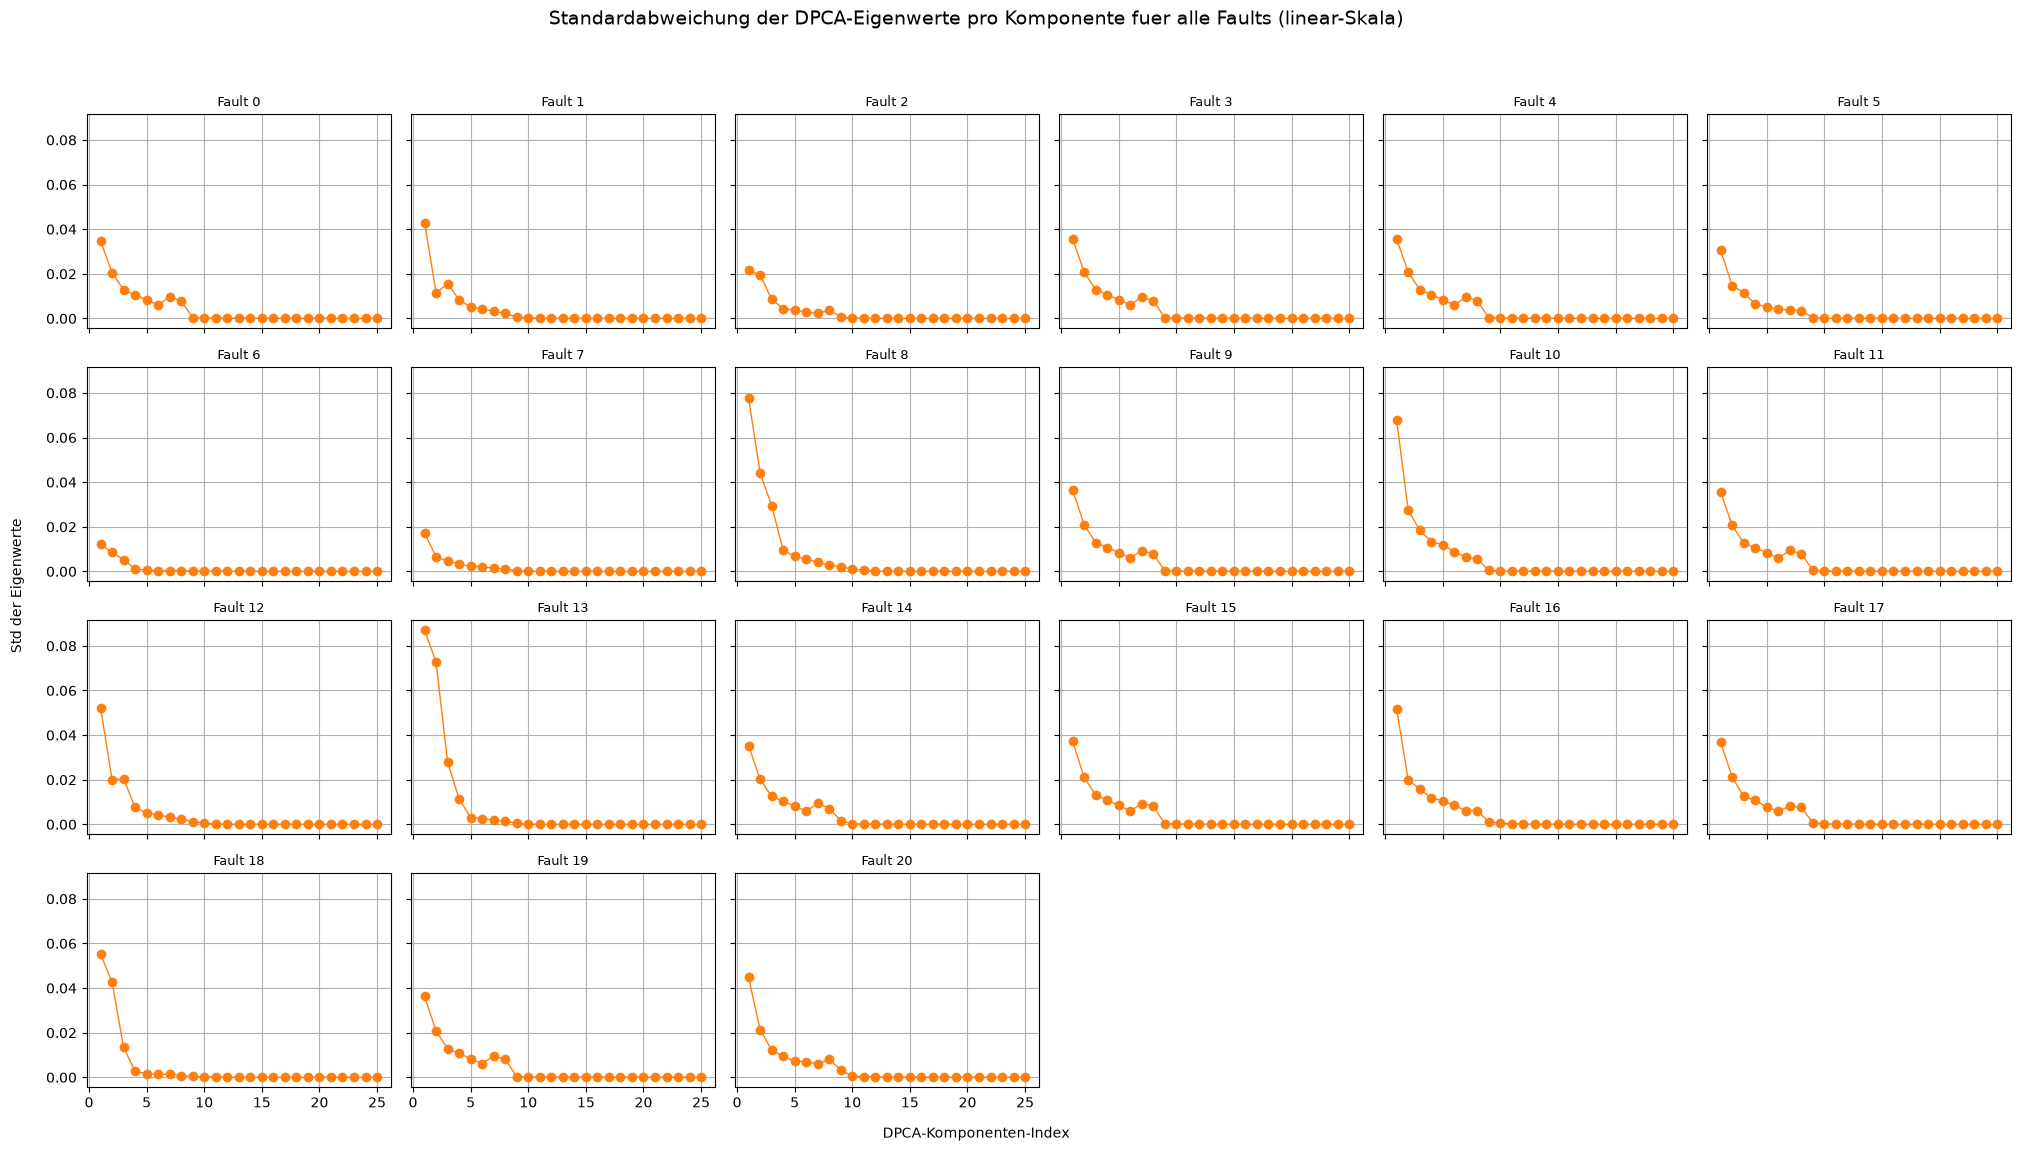

In [10]:
# ============================================================
# Visualisierung: ein Subplot pro Fehlerklasse, jeweils der Verlauf
# der STANDARDABWEICHUNG der Eigenwerte ueber die ersten k Komponenten.
# Struktur identisch zum Mittelwerts-Plot oben; geplottet wird hier
# die *_std-Statistik aus `agg` (orange, damit die Visualisierungen
# unterscheidbar sind).
# ============================================================

# Standardabweichungs-Spalten (dpca_i_std) heraussuchen und auf
# dieselben n_components wie beim Mittelwerts-Plot beschraenken.
std_cols = [
    c for c in agg.columns
    if c.startswith("dpca_") and c.endswith("_std")
]
std_cols = sorted(std_cols, key=lambda c: int(c.split("_")[1]))
std_cols = std_cols[:n_components]


# ============================================================
# Subplot-Raster aufbauen (gleiche Geometrie wie beim Mittelwerts-Plot)
# ============================================================
fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(3.5 * n_cols, 3.0 * n_rows),
    sharex=True,
    sharey=True,
)
axes = np.array(axes).reshape(-1)

for idx, f in enumerate(all_faults):
    ax  = axes[idx]
    row = agg[agg["faultNumber"] == f]

    if row.empty:
        ax.set_visible(False)
        continue

    stds   = row[std_cols].values.flatten()
    y_vals = transform_eigenvalues(stds, mode=plot_mode)

    # color="C1" -> Matplotlib-Standard-Orange.
    ax.plot(x, y_vals, marker="o", linewidth=1, color="C1")
    ax.set_title(f"Fault {f}", fontsize=9)
    ax.grid(True)

for j in range(idx + 1, len(axes)):
    axes[j].set_visible(False)

if plot_mode == "log":
    y_label = "log10(Std der Eigenwerte)"
elif plot_mode == "relative":
    y_label = "Std-Verhaeltnis (Std_i / Std_1)"
else:
    y_label = "Std der Eigenwerte"

fig.suptitle(
    f"Standardabweichung der DPCA-Eigenwerte pro Komponente fuer alle Faults ({plot_mode}-Skala)",
    fontsize=14,
)
fig.text(0.5,  0.04, "DPCA-Komponenten-Index", ha="center")
fig.text(0.04, 0.5,  y_label, va="center", rotation="vertical")

plt.tight_layout(rect=[0.05, 0.05, 1.0, 0.95])
plt.show()

# Visualisierung: relative Streuung (Variationskoeffizient) je Fehlerklasse #

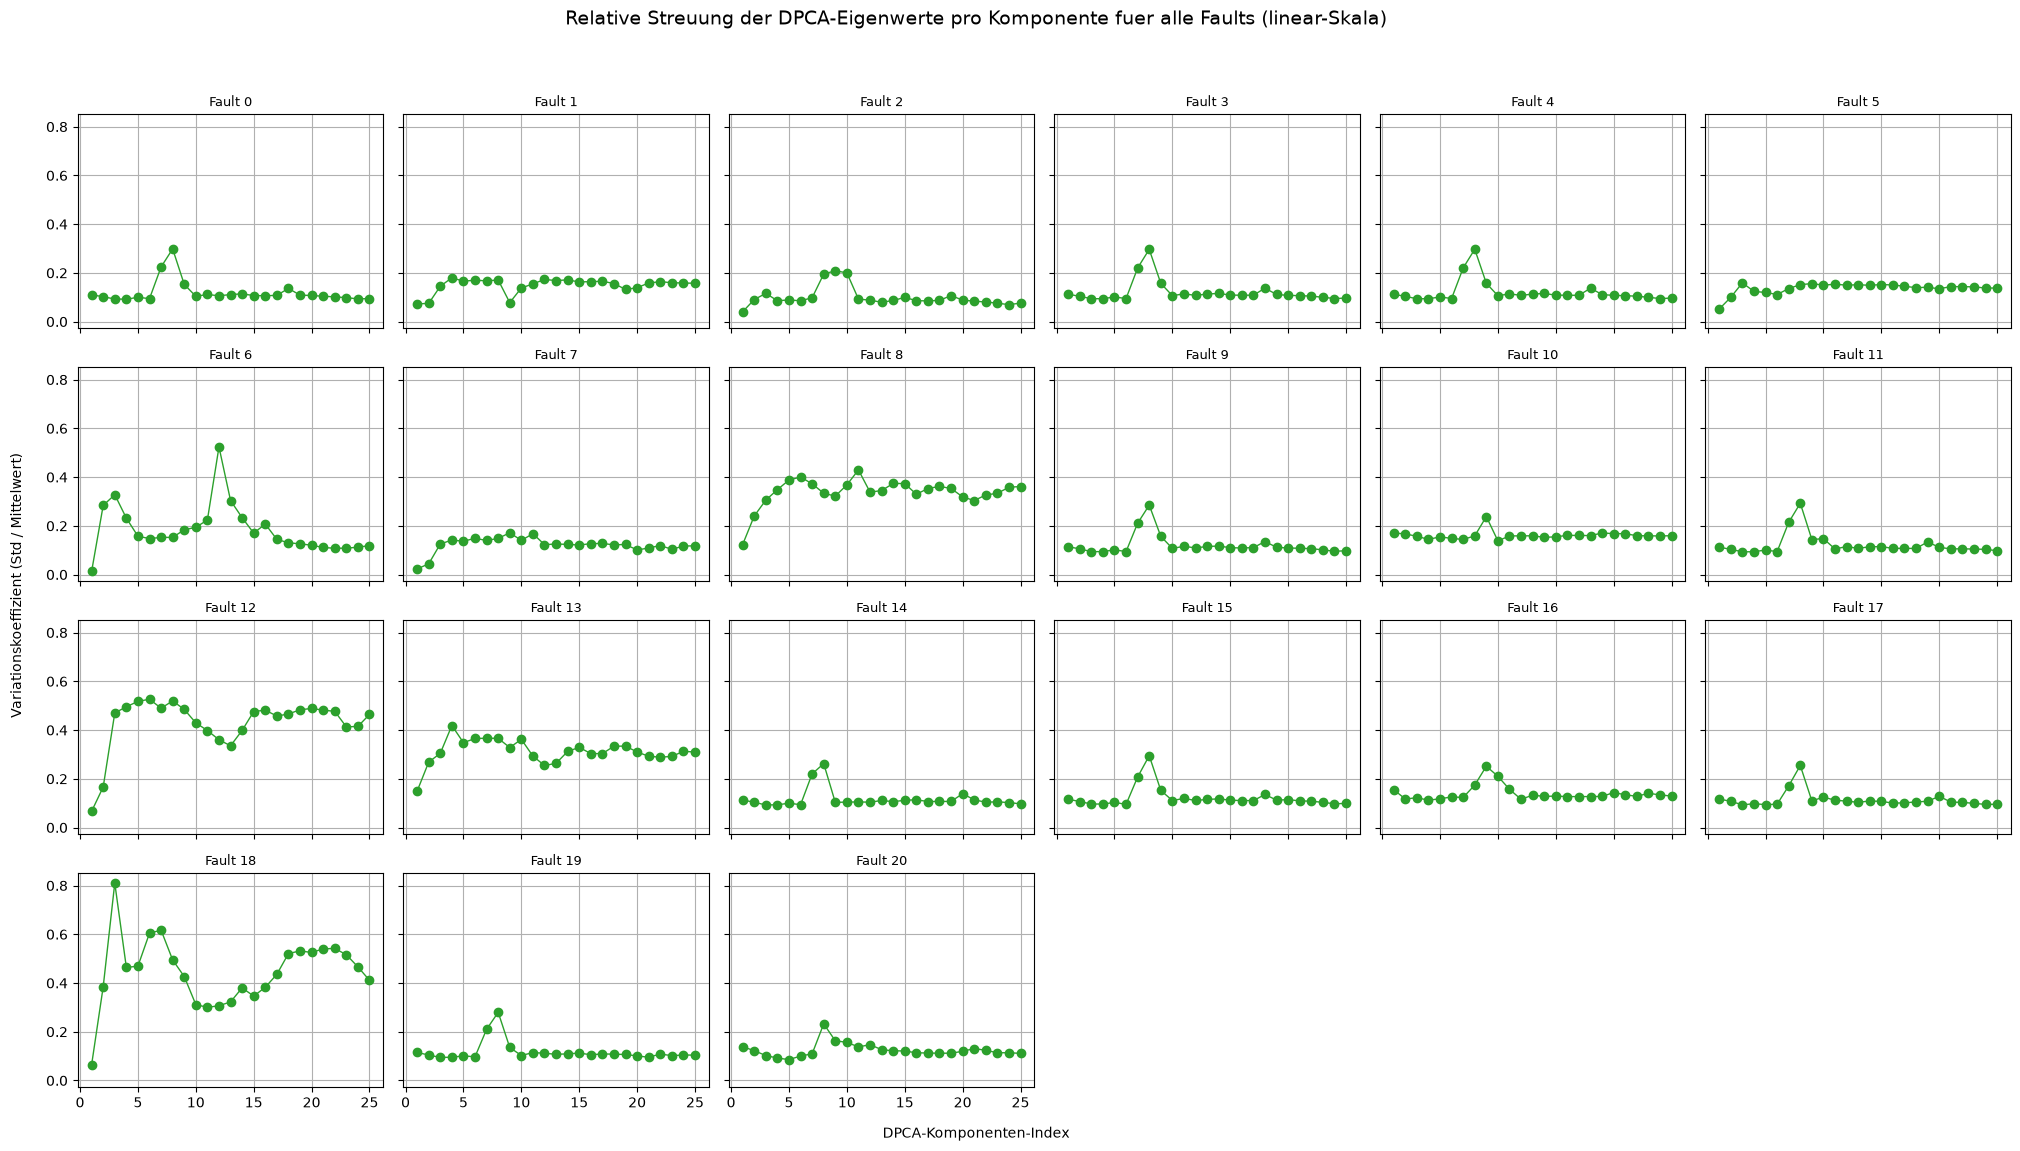

In [11]:
# ============================================================
# Visualisierung: ein Subplot pro Fehlerklasse, jeweils der Verlauf
# der RELATIVEN STREUUNG (Variationskoeffizient) der Eigenwerte
# ueber die ersten k Komponenten.
#
#     CV_i = dpca_i_std / dpca_i_mean
#
# Interpretation:
#   - Klein (z.B. < 0.1): Eigenwert ist ueber alle 500 Runs sehr stabil.
#   - Gross (z.B. > 0.5): Eigenwert schwankt von Run zu Run stark.
#
# Farbschema wie in den anderen Notebooks: blau = Mittelwert,
# orange = Std, gruen = CV.
# ============================================================

# Eigener Skalen-Modus - bewusst LINEAR, weil CVs dimensionslose
# Verhaeltnisse im Bereich 0..1 sind.
plot_mode_cv = "linear"

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(3.5 * n_cols, 3.0 * n_rows),
    sharex=True,
    sharey=True,
)
axes = np.array(axes).reshape(-1)

for idx, f in enumerate(all_faults):
    ax  = axes[idx]
    row = agg[agg["faultNumber"] == f]

    if row.empty:
        ax.set_visible(False)
        continue

    means = row[mean_cols].values.flatten()
    stds  = row[std_cols].values.flatten()

    # CV elementweise; PCA-Eigenwerte sind >= 0, np.errstate schuetzt
    # nur vor numerischen Entartungen im Noise-Tail.
    with np.errstate(divide="ignore", invalid="ignore"):
        cv = np.where(means > 0, stds / means, np.nan)

    y_vals = transform_eigenvalues(cv, mode=plot_mode_cv)

    # color="C2" -> Matplotlib-Standard-Gruen.
    ax.plot(x, y_vals, marker="o", linewidth=1, color="C2")
    ax.set_title(f"Fault {f}", fontsize=9)
    ax.grid(True)

for j in range(idx + 1, len(axes)):
    axes[j].set_visible(False)

if plot_mode_cv == "log":
    y_label = "log10(CV) = log10(Std / Mittelwert)"
elif plot_mode_cv == "relative":
    y_label = "CV_i / CV_1"
else:
    y_label = "Variationskoeffizient (Std / Mittelwert)"

fig.suptitle(
    f"Relative Streuung der DPCA-Eigenwerte pro Komponente fuer alle Faults ({plot_mode_cv}-Skala)",
    fontsize=14,
)
fig.text(0.5,  0.04, "DPCA-Komponenten-Index", ha="center")
fig.text(0.04, 0.5,  y_label, va="center", rotation="vertical")

plt.tight_layout(rect=[0.05, 0.05, 1.0, 0.95])
plt.show()

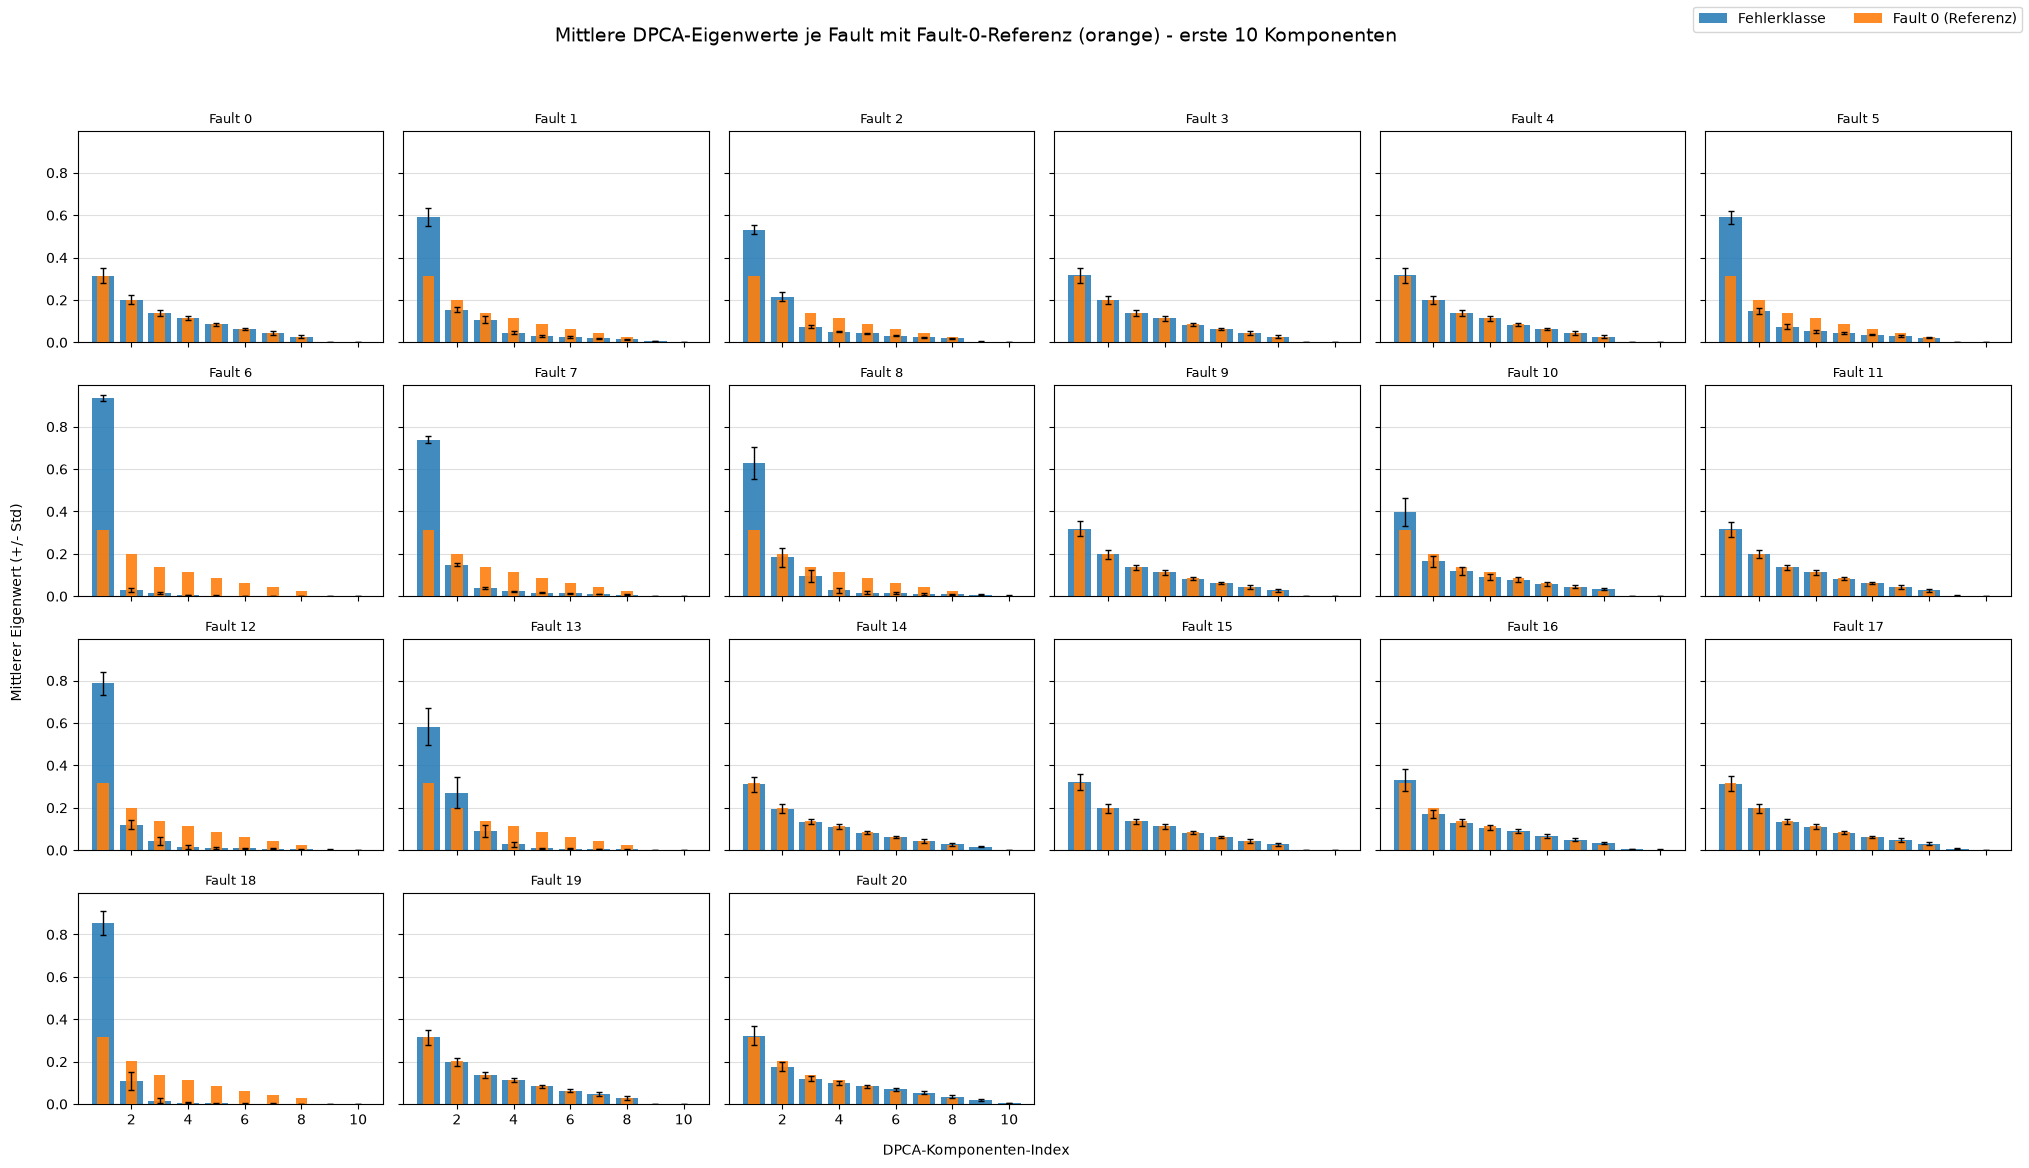

In [12]:
# ============================================================
# Bar-Plot: erste k Eigenwerte je Fault MIT Fault-0-Overlay (Referenz)
# ============================================================
# Pro Fehlerklasse ein Subplot:
#   - breite blaue Balken  = mittlerer DPCA-Eigenwert der Klasse,
#   - schmale orange Balken= Eigenwert-Mittelwert von Fault 0 (Normal-
#                            betrieb), zentriert oben drauf als Referenz,
#   - schwarze Fehlerbalken= +/- Std ueber die Runs der Klasse, werden
#                            ZULETZT gezeichnet (hoechster zorder), damit
#                            sie nicht vom orange Balken verdeckt werden.
# So ist je Fault direkt ablesbar, welche der ersten k Komponenten
# gegenueber dem fehlerfreien Betrieb abweichen.
#
# Lesehilfe: Faults, deren orange Referenz fast deckungsgleich mit den
# blauen Balken ist, sind anhand des Eigenwertspektrums kaum vom Normal-
# betrieb zu unterscheiden. Der Subplot "Fault 0" zeigt die Referenz auf
# sich selbst (perfekte Ueberlappung) - dient als Sanity-Check.

k_bar = 10
mean_cols_bar = [f"dpca_{i}_mean" for i in range(1, k_bar + 1)]
std_cols_bar  = [f"dpca_{i}_std"  for i in range(1, k_bar + 1)]

faults   = sorted(agg["faultNumber"].unique())
n_faults = len(faults)
ncols    = 6
nrows    = int(np.ceil(n_faults / ncols))

# Referenz-Spektrum: Mittelwerte von Fault 0 (Normalbetrieb).
ref_means = agg[agg["faultNumber"] == 0].iloc[0][mean_cols_bar].values.astype(float)

x = np.arange(1, k_bar + 1)

fig, axes = plt.subplots(
    nrows, ncols,
    figsize=(3.5 * ncols, 3.0 * nrows),
    sharex=True, sharey=True,
)
axes = np.array(axes).reshape(-1)

for i, f in enumerate(faults):
    ax  = axes[i]
    row = agg[agg["faultNumber"] == f].iloc[0]
    means = row[mean_cols_bar].values.astype(float)
    stds  = row[std_cols_bar].values.astype(float)

    # Klasse f: breite Balken (blau), OHNE yerr (Fehlerbalken kommen unten).
    ax.bar(x, means, width=0.8,
           color="C0", alpha=0.85,
           label="Fehlerklasse", zorder=2)
    # Fault 0 (Referenz): schmale orange Balken oben drauf.
    ax.bar(x, ref_means, width=0.4,
           color="tab:orange", alpha=0.9,
           label="Fault 0 (Referenz)", zorder=3)
    # Std-Fehlerbalken ZULETZT -> liegen sichtbar ueber dem orange Balken.
    ax.errorbar(x, means, yerr=stds, fmt="none",
                ecolor="black", capsize=2, elinewidth=1, zorder=4)

    ax.set_title(f"Fault {f}", fontsize=9)
    ax.grid(True, axis="y", alpha=0.4)

# Unbenutzte Achsen ausblenden (21 Faults in 4x6-Raster).
for j in range(n_faults, len(axes)):
    axes[j].set_visible(False)

# Gemeinsame Legende (generische Labels aus dem ersten Subplot).
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper right", ncol=2, fontsize=10)

fig.suptitle(
    f"Mittlere DPCA-Eigenwerte je Fault mit Fault-0-Referenz (orange) "
    f"- erste {k_bar} Komponenten",
    fontsize=14,
)
fig.text(0.5,  0.04, "DPCA-Komponenten-Index", ha="center")
fig.text(0.04, 0.5,  "Mittlerer Eigenwert (+/- Std)", va="center", rotation="vertical")

plt.tight_layout(rect=[0.05, 0.05, 1.0, 0.95])
plt.show()

# Export: Train-Eigenwerte (für LazyClassifier)

Stellt die berechneten **Trainings**-Eigenwerte als CSV bereit. Die
**Test**-Eigenwerte werden bewusst NICHT hier berechnet, sondern — analog zum
Vorgehen in `LazyClassifier_PCA_DyCA.ipynb` — in einem LazyClassifier-Notebook
mit Cutoff 161 und Fenster-Angleich; dieses Notebook bleibt auf die
Trainings-Analyse beschränkt.

In [13]:
# ============================================================
# Export: DPCA-Eigenwerte (Training) als CSV
# ============================================================
dpca_eigenvalues_per_run.to_csv("dpca_eigenvalues_train.csv", index=False)
print("DPCA-Train gespeichert:", dpca_eigenvalues_per_run.shape,
      "-> dpca_eigenvalues_train.csv")

DPCA-Train gespeichert: (10500, 158) -> dpca_eigenvalues_train.csv
